#Het Shah
#25070126513
#AIML B1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset('diamonds')
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['color'] = le.fit_transform(df['color'])
df['clarity'] = le.fit_transform(df['clarity'])
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,6,3,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,0,2,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,0,2,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,0,2,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,4,3,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
X=df.drop('cut',axis=1)
y=df['cut']

X_train,X_test, y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
dtm = DecisionTreeClassifier(random_state=42)
dtm.fit(X_train,y_train)

y_pred = dtm.predict(X_test)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.71
Classification Report:
               precision    recall  f1-score   support

        Fair       0.83      0.85      0.84       487
        Good       0.66      0.69      0.67      1500
       Ideal       0.79      0.79      0.79      6487
     Premium       0.73      0.72      0.73      4142
   Very Good       0.52      0.53      0.53      3566

    accuracy                           0.71     16182
   macro avg       0.71      0.72      0.71     16182
weighted avg       0.71      0.71      0.71     16182

Confusion Matrix:
 [[ 416   50    5    8    8]
 [  52 1035   49   49  315]
 [  11   33 5126  497  820]
 [   9   70  508 2994  561]
 [  15  381  760  529 1881]]


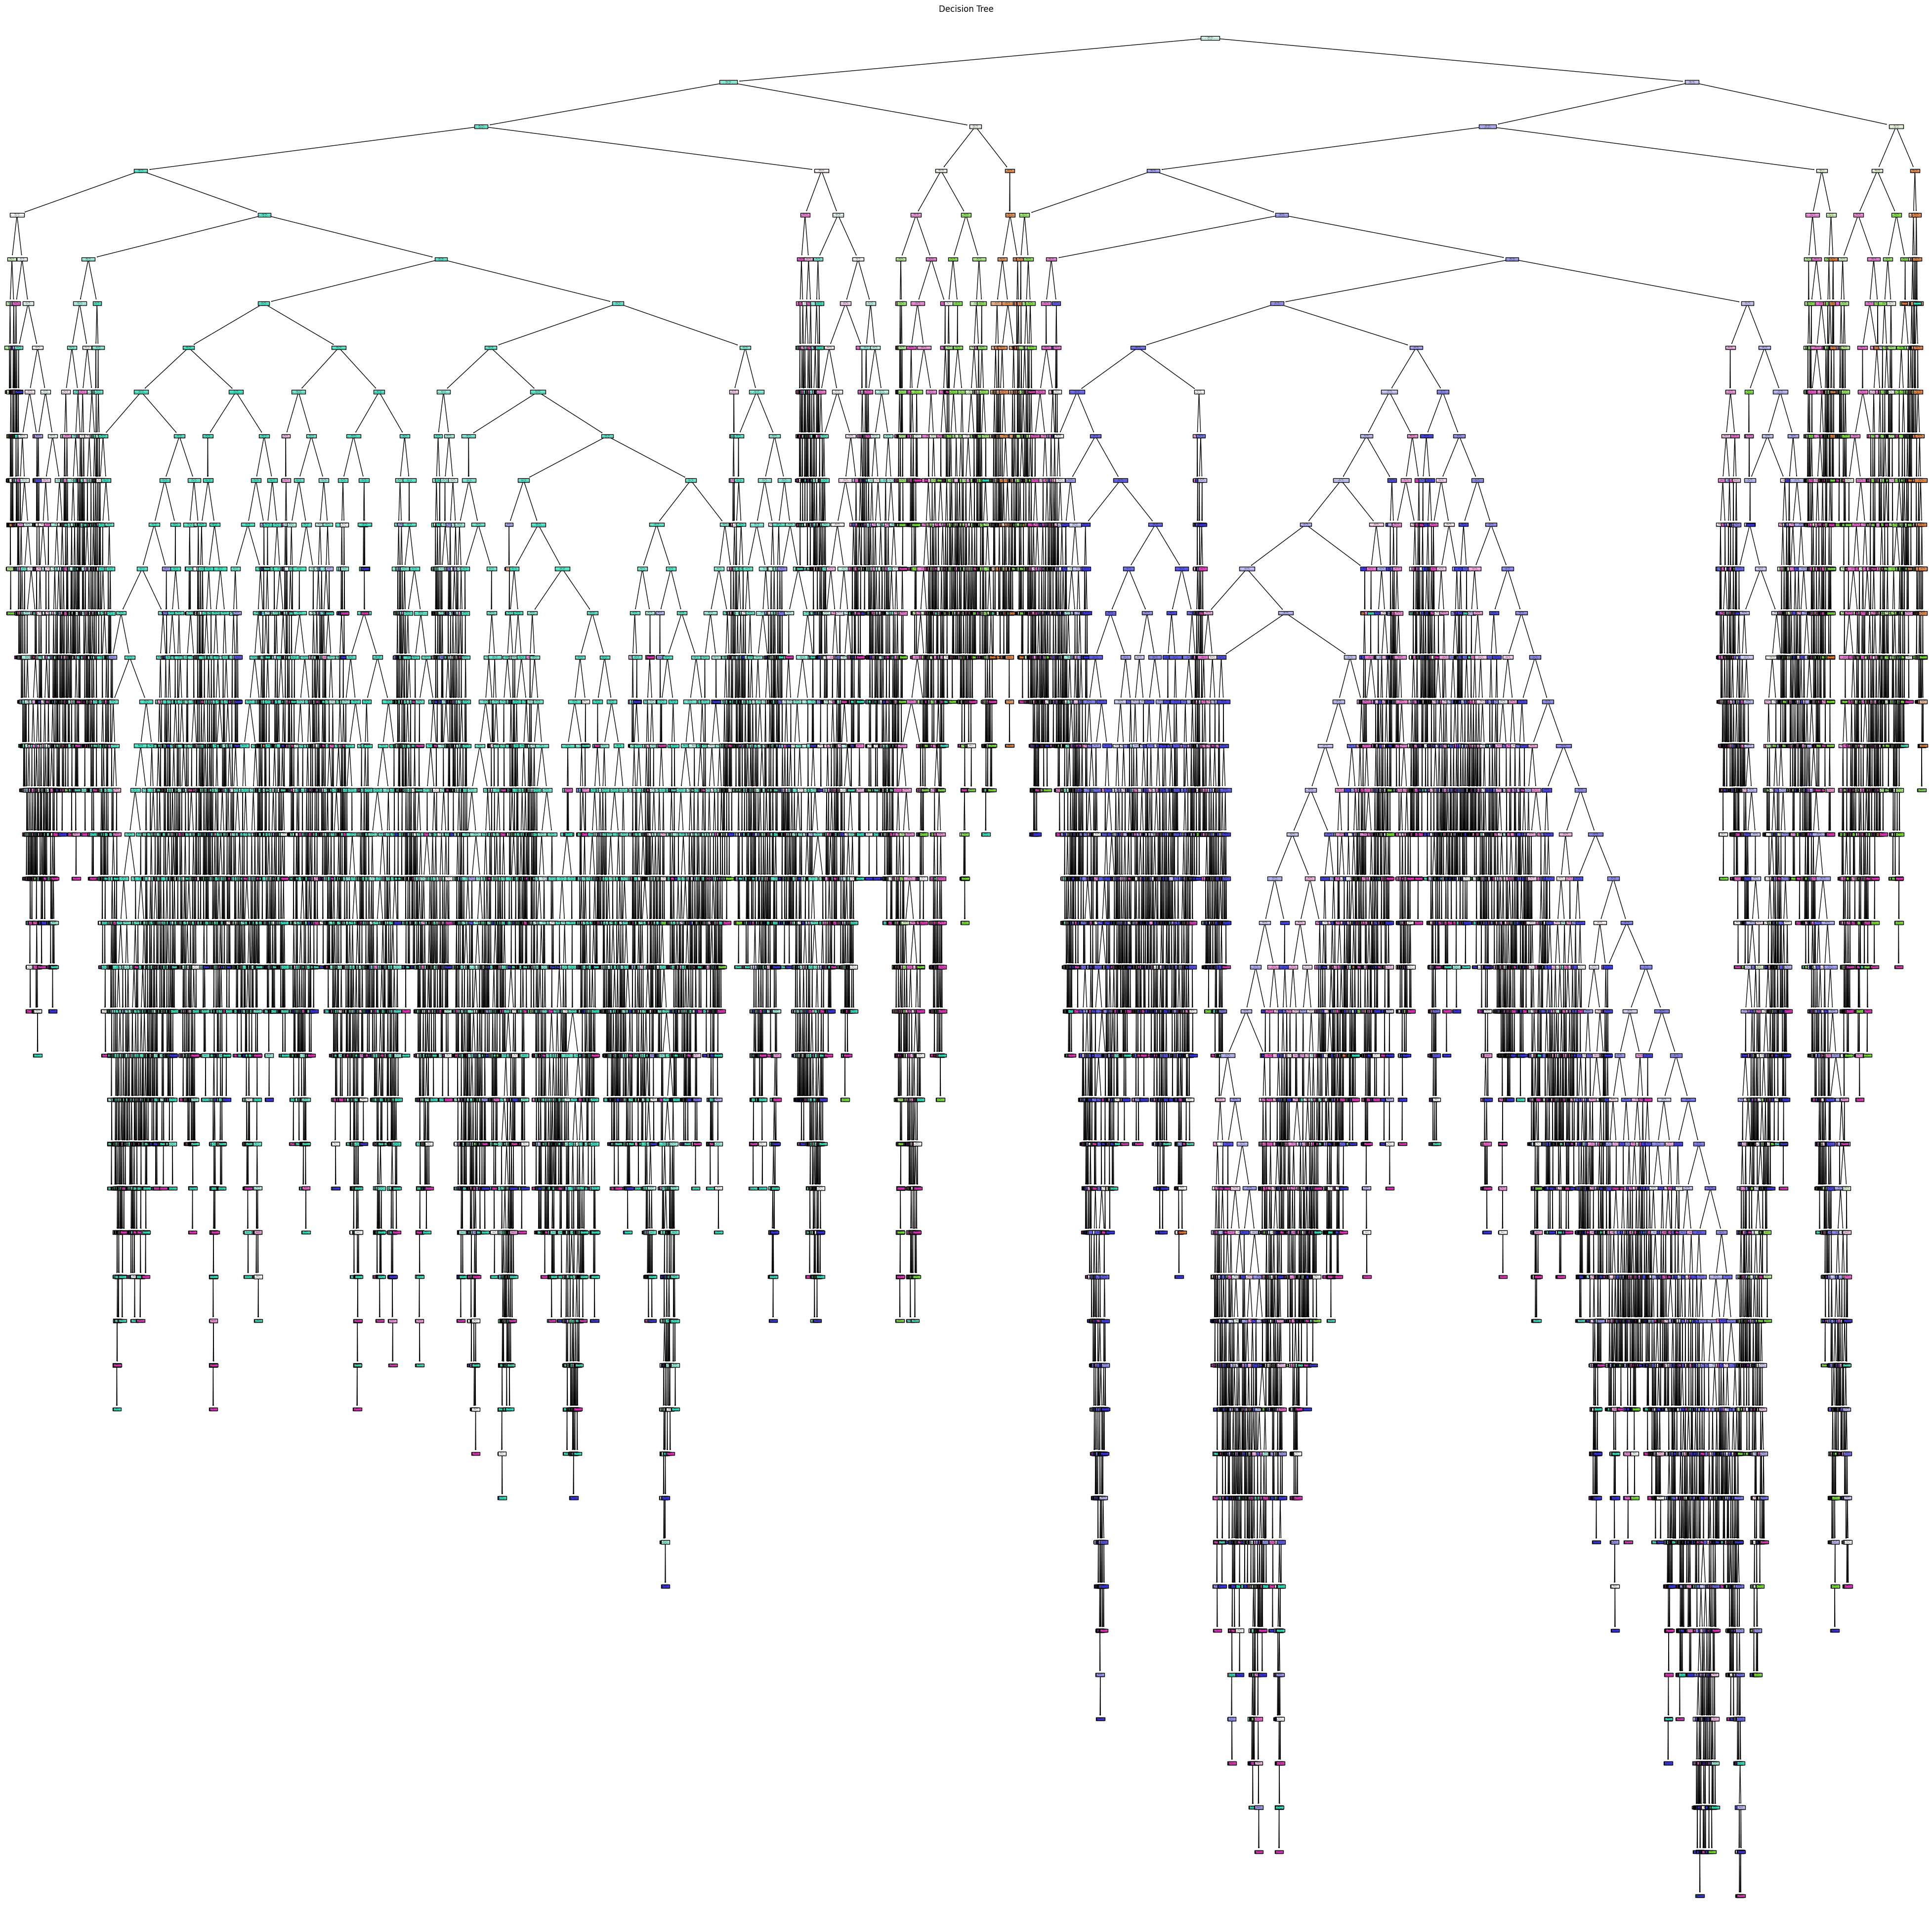

Depth of Tree: 42


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot decision tree
plt.figure(figsize=(50, 50))
plot_tree(dtm,feature_names=X.columns.tolist(),
    class_names=[str(c) for c in dtm.classes_],filled=True)
plt.title("Decision Tree")
plt.show()

# Depth of tree
print("Depth of Tree:", dtm.get_depth())